In [2]:
from statsmodels.tsa.seasonal import seasonal_decompose, STL
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.stattools import adfuller
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

## GOOGL の終値データの読み込み

In [3]:
df = pd.read_csv('./data/GOOGL.csv')
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2020-04-27,1292.000000,1294.099976,1265.060059,1270.859985,1270.859985,2209300
1,2020-04-28,1283.199951,1284.760010,1230.380005,1232.589966,1232.589966,4035000
2,2020-04-29,1345.000000,1360.150024,1326.729980,1342.180054,1342.180054,5417900
3,2020-04-30,1331.359985,1350.000000,1321.500000,1346.699951,1346.699951,2792100
4,2020-05-01,1324.089966,1351.430054,1309.660034,1317.319946,1317.319946,2443600


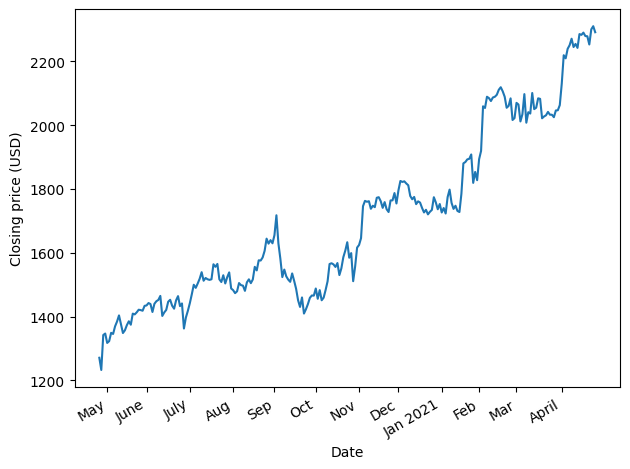

In [4]:
# プロットしてみる
fig, ax = plt.subplots()

ax.plot(df['Date'], df['Close'])
ax.set_xlabel('Date')
ax.set_ylabel('Closing price (USD)')

plt.xticks(
    [4, 24, 46, 68, 89, 110, 132, 152, 174, 193, 212, 235], 
    ['May', 'June', 'July', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec', 'Jan 2021', 'Feb', 'Mar', 'April'])

fig.autofmt_xdate()
plt.tight_layout()

plt.savefig('figures/googl.png', dpi=300)

## ランダムウォークプロセスのシュミレート

In [5]:
np.random.seed(42)

# シュミレートするプロセスの長さとして、1000個のサンプルを生成
# standard_normalで、乱数を正規分布から生成する。
steps = np.random.standard_normal(1000)

# 時系列の最初の値を0で初期化
steps[0]=0

# 累積和を計算することで、ランダムウォークのシミュレーションを行う
random_walk = np.cumsum(steps)

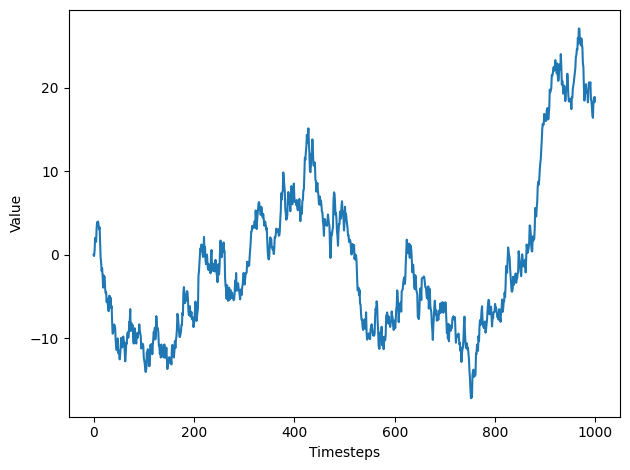

In [6]:
# シミュレーション結果をプロットしてみる
fig, ax = plt.subplots()

ax.plot(random_walk)
ax.set_xlabel('Timesteps')
ax.set_ylabel('Value')

plt.tight_layout()
plt.savefig('figures/simulate.png', dpi=300)

## ランダムウォークを予測する

In [8]:
# シミュレートしたランダムウォークをDataframeに読み込む
# 列はvalueのみ
df = pd.DataFrame({'value': random_walk})

# データの最初の80%を訓練データセットに割り当てる: 全部で1,000時間ステップ
# あるので、80%のデータはインデックス800までの値に相当する
train = df[:800]
test = df[800:]

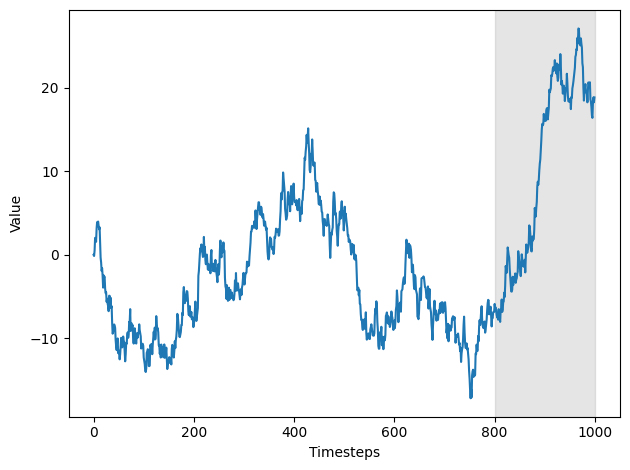

In [9]:
fig, ax = plt.subplots()

ax.plot(random_walk)
ax.set_xlabel('Timesteps')
ax.set_ylabel('Value')
ax.axvspan(800, 1000, color='#808080', alpha=0.2)

plt.tight_layout()
plt.savefig('figures/googl_randomwlak.png', dpi=300)

過去の平均値によって、予測する。

In [ ]:
# 訓練データセットの平均値を計算
mean = np.mean(train.value)

# 次の200時間ステップの予測値として過去の平均値を割り当てる
test.loc[:, 'pred_mean'] = mean

# テストデータセットの最初の５行を表示
test.head()

,value,pred_mean
800,-5.876664,-3.677206
801,-6.392708,-3.677206
802,-6.296588,-3.677206
803,-6.758863,-3.677206
804,-7.193359,-3.677206


過去の平均値は「-3.68」になる。

最後の既知の値を使って、予測する。

In [14]:
last_value = train.iloc[-1].value

test.loc[:, 'pred_last'] = last_value

test.head()

,value,pred_mean,pred_last
800,-5.876664,-3.677206,-6.814947
801,-6.392708,-3.677206,-6.814947
802,-6.296588,-3.677206,-6.814947
803,-6.758863,-3.677206,-6.814947
804,-7.193359,-3.677206,-6.814947


最後の既知の値にでは「-6.81」が予測値となる。

### ドリフト

最後の既知の値で予測する方法を改良したもの。

In [16]:
deltaX = 800 - 1
deltaY = last_value - 0

drift = deltaY / deltaX
print(drift)

-0.008529346056640647


In [ ]:
# 800から1000までの値を1ずつ生成
x_vals = np.arange(801, 1001, 1)

# ドリフトによる予測値を計算
pred_drift = drift * x_vals

test.loc[:, 'pred_drift'] = pred_drift

test.head()

,value,pred_mean,pred_last,pred_drift
800,-5.876664,-3.677206,-6.814947,-6.832006
801,-6.392708,-3.677206,-6.814947,-6.840536
802,-6.296588,-3.677206,-6.814947,-6.849065
803,-6.758863,-3.677206,-6.814947,-6.857594
804,-7.193359,-3.677206,-6.814947,-6.866124


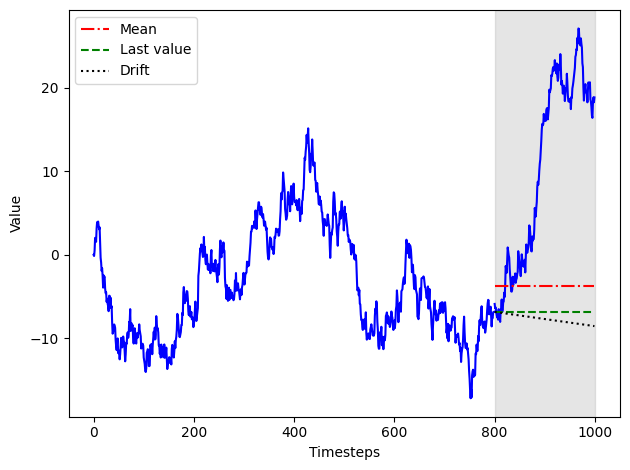

In [18]:
# ３つの予測方法を比較する
fig, ax = plt.subplots()

ax.plot(train.value, 'b-')
ax.plot(test['value'], 'b-')
ax.plot(test['pred_mean'], 'r-.', label='Mean')
ax.plot(test['pred_last'], 'g--', label='Last value')
ax.plot(test['pred_drift'], 'k:', label='Drift')

ax.axvspan(800, 1000, color='#808080', alpha=0.2)
ax.legend(loc=2)

ax.set_xlabel('Timesteps')
ax.set_ylabel('Value')

plt.tight_layout()
plt.savefig('figures/googl_three.png', dpi=300)

いずれの手法でも、テストデータセットで観測された急激な上昇を予測できていない。
ランダムウォークでの未来の変化は完全にランダムなんで、当然の結果。